## 03 Embedding Benchmark

This notebook benchmarks lexical and embedding-based similarity methods for curriculum overlap detection on the JAMK ICT course-pair dataset.

### Main goal

The purpose of Notebook 03 is to evaluate **score quality**, not final threshold decisions.

It answers:

> Which text representation and model combination produces similarity scores that best separate meaningful overlap pairs from non-overlap pairs?

### What this notebook does

- loads the cleaned course dataset from Notebook 01
- loads the labeled pair dataset from Notebook 02
- creates a fixed **course-level** dev/test split
- discards mixed pairs where one course is in dev and the other is in test
- benchmarks:
  - TF-IDF baseline
  - OpenAI `text-embedding-3-large`
  - `intfloat/multilingual-e5-base`
  - `intfloat/multilingual-e5-large`
  - `BAAI/bge-m3`
- compares three text variants:
  - `embedding_text_compact`
  - `embedding_text_main`
  - `embedding_text_with_prerequisites`
- computes pairwise cosine similarity scores
- evaluates ranking quality on the **development split only**
- saves benchmark tables and figures for Notebook 04

### What this notebook does not do

- it does not choose the final production threshold
- it does not finalize the classifier decision rule
- it does not report final locked test-set threshold performance
- it does not rebalance the naturally imbalanced dataset

### Important methodological note

The dataset is strongly imbalanced because meaningful curriculum overlap is relatively rare in the real course set. For that reason, **raw accuracy is not the main metric** in this notebook.

The primary focus is on:

- Average Precision / PR-AUC
- ROC-AUC as a secondary ranking metric
- score separation between positives and negatives
- qualitative inspection of top-ranked pairs and hard false positives

### Split design

This notebook uses a **course-level split** rather than a pair-level split.

That means:
- a course is assigned either to dev or to test
- a pair is assigned to dev only if both courses are in dev
- a pair is assigned to test only if both courses are in test
- mixed pairs are excluded from benchmark evaluation

This is more conservative than a pair-level split and provides a more honest held-out evaluation.

### Similarity metric note

This notebook uses **cosine similarity** as the single comparison metric for all benchmarked methods. Dense embeddings are L2-normalized before scoring, so cosine similarity and dot product become equivalent for ranking in this context.

In [194]:
# Cell 02 - Import libraries and define project paths

from pathlib import Path
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer
from openai import OpenAI

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "benchmark"
TABLES_DIR = REPORTS_DIR / "tables" / "benchmark"
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
BENCHMARK_PAIRS_DIR = DATA_DIR / "benchmark_pairs"
SPLITS_DIR = DATA_DIR / "splits"

COURSES_CSV_PATH = DATA_DIR / "courses_clean.csv"
PAIRS_CSV_PATH = DATA_DIR / "gold_pairs_review_labeled.csv"
ENV_PATH = PROJECT_ROOT / ".env"

COURSE_SPLIT_CSV_PATH = SPLITS_DIR / "course_dev_test_split.csv"
PAIR_SPLIT_CSV_PATH = SPLITS_DIR / "pair_dev_test_split_course_level.csv"
PAIR_SCORES_CSV_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.csv"
PAIR_SCORES_PARQUET_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.parquet"
DEV_SUMMARY_CSV_PATH = TABLES_DIR / "benchmark_summary_dev.csv"
LEADERBOARD_CSV_PATH = TABLES_DIR / "benchmark_leaderboard_dev.csv"
TOP_PAIRS_CSV_PATH = TABLES_DIR / "top_ranked_dev_pairs_by_config.csv"
HARD_FALSE_POSITIVES_CSV_PATH = TABLES_DIR / "hard_false_positives_dev_top5_by_config.csv"
SHORTLIST_CSV_PATH = TABLES_DIR / "shortlist_for_notebook_04.csv"

for path in [FIGURES_DIR, TABLES_DIR, EMBEDDINGS_DIR, BENCHMARK_PAIRS_DIR, SPLITS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TEST_COURSE_FRACTION = 0.30
COURSE_SPLIT_SEARCH_TRIALS = 10000

# Split-quality targets
TARGET_MIN_TEST_POSITIVES = 5
FALLBACK_MIN_TEST_POSITIVES = 4
MIN_DEV_POSITIVES = 12

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Courses CSV:", COURSES_CSV_PATH)
print("Pairs CSV:", PAIRS_CSV_PATH)
print("Environment file:", ENV_PATH)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)
print("Embeddings dir:", EMBEDDINGS_DIR)

Project root: C:\Users\user\Downloads\curriculum-overlap-poc
Courses CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\courses_clean.csv
Pairs CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\gold_pairs_review_labeled.csv
Environment file: C:\Users\user\Downloads\curriculum-overlap-poc\.env
Figures dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\benchmark
Tables dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark
Embeddings dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings


### Environment setup

This notebook supports both:

- local open-source embedding models
- OpenAI embedding API evaluation

Expected `.env` file location:

`curriculum-overlap-poc/.env`

Expected variable:

- `OPENAI_API_KEY`

In [195]:
# Cell 04 - Load environment variables and initialize OpenAI client if available

load_dotenv(ENV_PATH)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

openai_client = None
if OPENAI_API_KEY:
    openai_client = OpenAI(api_key=OPENAI_API_KEY)
    print("OpenAI API key loaded: Yes")
else:
    print("OpenAI API key loaded: No")

USE_OPENAI_MODEL = bool(OPENAI_API_KEY)
print("Use OpenAI benchmark:", USE_OPENAI_MODEL)

OpenAI API key loaded: Yes
Use OpenAI benchmark: True


### Load datasets

This notebook uses:

- `courses_clean.csv` from Notebook 01
- `gold_pairs_review_labeled.csv` from Notebook 02

In [196]:
# Cell 06 - Load datasets

courses_df = pd.read_csv(COURSES_CSV_PATH, encoding="utf-8", keep_default_na=False)
pairs_df = pd.read_csv(PAIRS_CSV_PATH, encoding="utf-8", keep_default_na=False)

print("courses_df shape:", courses_df.shape)
print("pairs_df shape:", pairs_df.shape)

display(courses_df.head(2))
display(pairs_df.head(2))

courses_df shape: (50, 20)
pairs_df shape: (1225, 10)


,degree_programme,course_name,course_unit_code,credits,teaching_language_text,responsible_person_text,objective_text,competences_knowledge_text,competences_practice_text,content_text,prerequisites_text,assessment_grading_scale,assessment_pass_fail_criteria,course_name_normalized,prerequisites_text_normalized,embedding_text_compact,embedding_text_main,embedding_text_with_prerequisites,review_text_compact,review_text_full
0,Information and Communication Technology,Data Networks,TT00CD70,5,"Finnish, English",Pasi Hyytiäinen,You learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data network. You are ...,You know the main modeling methods of data networks. You have knowledge and understanding of data networks and their effects. You know the basic principles ...,You can apply data network skills to communication between devices.,Principles of network structure and protocol design. Principles of Internet communication. OSI model layers. Design and implementation of local area network...,Linux Basics,1-5,The student has sufficient knowledge of the theory on network protocols and is able to recognize some sections of existing solutions. The student can design...,data networks,linux basics,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Course code: TT00CD70\nCourse name: Data Networks\nObjective: You learn the structure and protocols of data networks used by computers and other end devices...,Course code: TT00CD70\nCourse name: Data Networks\nObjective: You learn the structure and protocols of data networks used by computers and other end devices...
1,Information and Communication Technology,Linux Basics,TT00CD71,4,"Finnish, English","Juho Pekki, Teemu Siikaniemi","After completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work with and manage t...",You understand the key concepts and architecture of the Linux operating system. You understand the importance of managing user accounts and groups.,You know how to manage the key functions of the Linux system and use command-line tools. You know how to manage the filesystem and user account permissions....,"In this course, you will learn how to effectively manage the Linux operating system using a text-based interface. You will understand key concepts and be ab...",,1-5,,linux basics,,"Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Course code: TT00CD71\nCourse name: Linux Basics\nObjective: After completing the course, you will understand the most important concepts of the Linux opera...","Course code: TT00CD71\nCourse name: Linux Basics\nObjective: After completing the course, you will understand the most important concepts of the Linux opera..."


,pair_id,course_unit_code_1,course_name_1,review_text_1,course_unit_code_2,course_name_2,review_text_2,overlap_label,review_status,review_notes
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,Course code: TT00CD70 | Course name: Data Networks | Objective: You learn the structure and protocols of data networks used by computers and other end devic...,TT00CD71,Linux Basics,"Course code: TT00CD71 | Course name: Linux Basics | Objective: After completing the course, you will understand the most important concepts of the Linux ope...",0,reviewed,
1,TT00CD70__TT00CD72,TT00CD70,Data Networks,Course code: TT00CD70 | Course name: Data Networks | Objective: You learn the structure and protocols of data networks used by computers and other end devic...,TT00CD72,Servers and containers,Course code: TT00CD72 | Course name: Servers and containers | Objective: You understand the fundamental types and functions of servers. You understand the k...,0,reviewed,


In [197]:
# Cell 07 - Validate required columns

required_course_columns = [
    "course_unit_code",
    "course_name",
    "embedding_text_compact",
    "embedding_text_main",
    "embedding_text_with_prerequisites",
]

required_pair_columns = [
    "pair_id",
    "course_unit_code_1",
    "course_name_1",
    "course_unit_code_2",
    "course_name_2",
    "overlap_label",
    "review_status",
    "review_notes",
]

missing_course_columns = [col for col in required_course_columns if col not in courses_df.columns]
missing_pair_columns = [col for col in required_pair_columns if col not in pairs_df.columns]

if missing_course_columns:
    raise ValueError(f"Missing required course columns: {missing_course_columns}")

if missing_pair_columns:
    raise ValueError(f"Missing required pair columns: {missing_pair_columns}")

if courses_df["course_unit_code"].duplicated().any():
    raise ValueError("Duplicate course_unit_code values found in courses_df.")

if pairs_df["pair_id"].duplicated().any():
    raise ValueError("Duplicate pair_id values found in pairs_df.")

print("All required columns are present.")

All required columns are present.


In [198]:
# Cell 08 - Normalize labels and review status

def normalize_overlap_label(value):
    text = str(value).strip().lower()
    if text in {"1", "true", "yes", "overlap"}:
        return 1
    if text in {"0", "false", "no", "none", "no overlap"}:
        return 0
    return np.nan

pairs_df["overlap_label_binary"] = pairs_df["overlap_label"].apply(normalize_overlap_label)

invalid_label_count = pairs_df["overlap_label_binary"].isna().sum()
if invalid_label_count > 0:
    raise ValueError(f"Found {invalid_label_count} invalid overlap_label values.")

reviewed_count = (pairs_df["review_status"].astype(str).str.strip().str.lower() == "reviewed").sum()

print("Rows with valid binary label:", len(pairs_df))
print("Reviewed rows:", reviewed_count)
print("Positive labels:", int(pairs_df["overlap_label_binary"].sum()))
print("Negative labels:", int((pairs_df["overlap_label_binary"] == 0).sum()))

display(pairs_df["overlap_label_binary"].value_counts().sort_index())

Rows with valid binary label: 1225
Reviewed rows: 1225
Positive labels: 28
Negative labels: 1197


overlap_label_binary
0    1197
1      28
Name: count, dtype: int64

### Create a fixed course-level dev/test split

This notebook uses a **course-level split** rather than splitting pairs directly.

A pair is assigned:
- `dev` if both courses belong to the dev course set
- `test` if both courses belong to the test course set
- `mixed_discard` if one course is in dev and the other is in test

Mixed pairs are excluded from benchmark evaluation.

#### Important note about split construction

Because the labeled dataset is small and positive overlap pairs are rare, the notebook uses a constrained search over deterministic random seeds to find a **course-level split that preserves a minimally usable number of positive pairs in both dev and test**.

This improves practical usability for Notebook 03 and Notebook 04, but it is not the same as a completely arbitrary single split. That should be acknowledged as a methodological limitation in the thesis.

In [199]:
# Cell 10 - Search for a course-level split that preserves usable positive pairs

all_course_codes = sorted(courses_df["course_unit_code"].tolist())
n_courses = len(all_course_codes)
n_test_courses = int(round(n_courses * TEST_COURSE_FRACTION))

positive_pairs_df = pairs_df[pairs_df["overlap_label_binary"] == 1].copy()

best_result = None

for trial in range(COURSE_SPLIT_SEARCH_TRIALS):
    rng = random.Random(RANDOM_SEED + trial)
    test_courses = set(rng.sample(all_course_codes, n_test_courses))
    dev_courses = set(all_course_codes) - test_courses

    pair_split_labels = []
    for _, row in pairs_df.iterrows():
        c1 = row["course_unit_code_1"]
        c2 = row["course_unit_code_2"]

        if c1 in dev_courses and c2 in dev_courses:
            pair_split_labels.append("dev")
        elif c1 in test_courses and c2 in test_courses:
            pair_split_labels.append("test")
        else:
            pair_split_labels.append("mixed_discard")

    temp_df = pairs_df[["pair_id", "overlap_label_binary"]].copy()
    temp_df["split"] = pair_split_labels

    dev_pos = int(temp_df.loc[(temp_df["split"] == "dev") & (temp_df["overlap_label_binary"] == 1)].shape[0])
    test_pos = int(temp_df.loc[(temp_df["split"] == "test") & (temp_df["overlap_label_binary"] == 1)].shape[0])
    dev_pairs = int((temp_df["split"] == "dev").sum())
    test_pairs = int((temp_df["split"] == "test").sum())
    usable_pairs = dev_pairs + test_pairs
    kept_positives = dev_pos + test_pos
    mixed_discard_pairs = int((temp_df["split"] == "mixed_discard").sum())

    feasible_target = (dev_pos >= MIN_DEV_POSITIVES) and (test_pos >= TARGET_MIN_TEST_POSITIVES) and (test_pairs > 0)
    feasible_fallback = (dev_pos >= MIN_DEV_POSITIVES) and (test_pos >= FALLBACK_MIN_TEST_POSITIVES) and (test_pairs > 0)

    candidate = {
        "trial": trial,
        "dev_courses": sorted(dev_courses),
        "test_courses": sorted(test_courses),
        "dev_pairs": dev_pairs,
        "test_pairs": test_pairs,
        "usable_pairs": usable_pairs,
        "mixed_discard_pairs": mixed_discard_pairs,
        "dev_positives": dev_pos,
        "test_positives": test_pos,
        "kept_positives": kept_positives,
        "feasible_target": feasible_target,
        "feasible_fallback": feasible_fallback,
    }

    if best_result is None:
        best_result = candidate
    else:
        current_key = (
            candidate["feasible_target"],
            candidate["feasible_fallback"],
            candidate["kept_positives"],
            candidate["dev_positives"],
            candidate["usable_pairs"],
            -abs(candidate["test_pairs"] - 105),
        )
        best_key = (
            best_result["feasible_target"],
            best_result["feasible_fallback"],
            best_result["kept_positives"],
            best_result["dev_positives"],
            best_result["usable_pairs"],
            -abs(best_result["test_pairs"] - 105),
        )

        if current_key > best_key:
            best_result = candidate

if best_result is None:
    raise ValueError("Failed to construct a course-level split.")

if best_result["feasible_target"]:
    split_selection_status = f"Target achieved: at least {TARGET_MIN_TEST_POSITIVES} test positives."
elif best_result["feasible_fallback"]:
    split_selection_status = (
        f"Fallback used: target of {TARGET_MIN_TEST_POSITIVES} test positives not found, "
        f"but at least {FALLBACK_MIN_TEST_POSITIVES} test positives was achieved."
    )
else:
    raise ValueError(
        "No feasible course-level split found that satisfies the minimum positive-pair requirements."
    )

split_summary_series = pd.Series({
    "split_selection_status": split_selection_status,
    "feasible_target": best_result["feasible_target"],
    "feasible_fallback": best_result["feasible_fallback"],
    "dev_pairs": best_result["dev_pairs"],
    "test_pairs": best_result["test_pairs"],
    "usable_pairs": best_result["usable_pairs"],
    "mixed_discard_pairs": best_result["mixed_discard_pairs"],
    "dev_positives": best_result["dev_positives"],
    "test_positives": best_result["test_positives"],
    "kept_positives": best_result["kept_positives"],
    "discarded_positives": int(positive_pairs_df.shape[0] - best_result["kept_positives"]),
})

print("Best course-level split found:")
display(split_summary_series)

print()
print("Interpretation:")
print(
    "This split was chosen to preserve a workable number of positives in both development and test. "
    "It is more defensible than a pair-level split, but it is still a constrained split search rather than a fully arbitrary single holdout."
)

Best course-level split found:


split_selection_status    Target achieved: at least 5 test positives.
feasible_target                                                  True
feasible_fallback                                                True
dev_pairs                                                         595
test_pairs                                                        105
usable_pairs                                                      700
mixed_discard_pairs                                               525
dev_positives                                                      21
test_positives                                                      5
kept_positives                                                     26
discarded_positives                                                 2
dtype: object


Interpretation:
This split was chosen to preserve a workable number of positives in both development and test. It is more defensible than a pair-level split, but it is still a constrained split search rather than a fully arbitrary single holdout.


In [200]:
# Cell 11 - Save course-level split and assign pair splits

course_split_df = pd.DataFrame({
    "course_unit_code": all_course_codes,
})
course_split_df["split"] = np.where(
    course_split_df["course_unit_code"].isin(best_result["test_courses"]),
    "test",
    "dev"
)

course_split_df.to_csv(COURSE_SPLIT_CSV_PATH, index=False, encoding="utf-8")

course_split_map = dict(zip(course_split_df["course_unit_code"], course_split_df["split"]))

pairs_df["course_split_1"] = pairs_df["course_unit_code_1"].map(course_split_map)
pairs_df["course_split_2"] = pairs_df["course_unit_code_2"].map(course_split_map)

def assign_pair_split(row):
    if row["course_split_1"] == "dev" and row["course_split_2"] == "dev":
        return "dev"
    if row["course_split_1"] == "test" and row["course_split_2"] == "test":
        return "test"
    return "mixed_discard"

pairs_df["split"] = pairs_df.apply(assign_pair_split, axis=1)

pairs_df[["pair_id", "split"]].to_csv(PAIR_SPLIT_CSV_PATH, index=False, encoding="utf-8")

print("Saved course split to:", COURSE_SPLIT_CSV_PATH)
print("Saved pair split to:", PAIR_SPLIT_CSV_PATH)

display(course_split_df["split"].value_counts())
display(
    pairs_df.groupby("split")["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

Saved course split to: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits\course_dev_test_split.csv
Saved pair split to: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits\pair_dev_test_split_course_level.csv


split
dev     35
test    15
Name: count, dtype: int64

,count,positive_count
split,,
dev,595,21
mixed_discard,525,2
test,105,5


In [201]:
# Cell 12 - Keep only usable benchmark pairs and show discarded positives

benchmark_pairs_df = pairs_df[pairs_df["split"].isin(["dev", "test"])].copy()

if benchmark_pairs_df.empty:
    raise ValueError("No usable benchmark pairs remain after course-level split.")

print("Usable benchmark pair counts:")
display(
    benchmark_pairs_df.groupby("split")["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

discarded_positive_pairs_df = pairs_df[
    (pairs_df["split"] == "mixed_discard") &
    (pairs_df["overlap_label_binary"] == 1)
][[
    "pair_id",
    "course_name_1",
    "course_name_2",
    "review_notes",
]].copy()

print("Discarded positive pairs:")
display(discarded_positive_pairs_df)

Usable benchmark pair counts:


,count,positive_count
split,,
dev,595,21
test,105,5


Discarded positive pairs:


,pair_id,course_name_1,course_name_2,review_notes
997,TT00CD98__TT00CE02,Mathematical Foundations of Machine Learning,Machine Learning: Regression Methods,"Both courses share core machine learning and statistical foundations. Mathematical Foundations of ML teaches probability, statistics, and linear algebra use..."
1054,TT00CE01__TT00CE02,Machine Learning: Classification Methods,Machine Learning: Regression Methods,"Both cover machine learning workflow fundamentals such as training, evaluation, and model performance analysis."


### Build the course-text dataframe

Each course is embedded once per model and text variant.
Those course embeddings are then reused to compute pairwise similarity scores.

In [202]:
# Cell 14 - Build course text dataframe

course_text_df = courses_df[[
    "course_unit_code",
    "course_name",
    "embedding_text_compact",
    "embedding_text_main",
    "embedding_text_with_prerequisites",
]].copy()

for col in ["embedding_text_compact", "embedding_text_main", "embedding_text_with_prerequisites"]:
    empty_count = (course_text_df[col].fillna("").astype(str).str.strip() == "").sum()
    print(f"Empty rows in {col}: {empty_count}")
    if empty_count > 0:
        raise ValueError(f"Found empty text rows in {col}.")

print("course_text_df shape:", course_text_df.shape)
display(course_text_df.head(3))

Empty rows in embedding_text_compact: 0
Empty rows in embedding_text_main: 0
Empty rows in embedding_text_with_prerequisites: 0
course_text_df shape: (50, 5)


,course_unit_code,course_name,embedding_text_compact,embedding_text_main,embedding_text_with_prerequisites
0,TT00CD70,Data Networks,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...
1,TT00CD71,Linux Basics,"Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit..."
2,TT00CD72,Servers and containers,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...


#### Benchmark configurations

Text variants:
- `compact`
- `main`
- `with_prerequisites`

Models:
- TF-IDF baseline
- OpenAI `text-embedding-3-large`
- `intfloat/multilingual-e5-base`
- `intfloat/multilingual-e5-large`
- `BAAI/bge-m3`

For the multilingual E5 models, this notebook uses a consistent `query: ` prefix for both compared course texts. This is appropriate here because the task is symmetric course-course similarity. For BGE-M3, no special prefix is added, consistent with the BAAI/bge-m3 model documentation.

In [203]:
# Cell 16 - Define benchmark configurations

TEXT_VARIANTS = {
    "compact": "embedding_text_compact",
    "main": "embedding_text_main",
    "with_prerequisites": "embedding_text_with_prerequisites",
}

MODEL_CONFIGS = [
    {"model_name": "tfidf", "model_type": "tfidf", "hf_id": None, "openai_id": None},
    {"model_name": "openai_text-embedding-3-large", "model_type": "openai", "hf_id": None, "openai_id": "text-embedding-3-large"},
    {"model_name": "multilingual-e5-base", "model_type": "sentence_transformer", "hf_id": "intfloat/multilingual-e5-base", "openai_id": None},
    {"model_name": "multilingual-e5-large", "model_type": "sentence_transformer", "hf_id": "intfloat/multilingual-e5-large", "openai_id": None},
    {"model_name": "bge-m3", "model_type": "sentence_transformer", "hf_id": "BAAI/bge-m3", "openai_id": None},
]

if not USE_OPENAI_MODEL:
    MODEL_CONFIGS = [cfg for cfg in MODEL_CONFIGS if cfg["model_type"] != "openai"]

print("Text variants:", list(TEXT_VARIANTS.keys()))
print("Models:", [cfg["model_name"] for cfg in MODEL_CONFIGS])

Text variants: ['compact', 'main', 'with_prerequisites']
Models: ['tfidf', 'openai_text-embedding-3-large', 'multilingual-e5-base', 'multilingual-e5-large', 'bge-m3']


In [204]:
# Cell 17 - Helper functions

def slugify_name(text: str) -> str:
    return text.lower().replace("/", "_").replace(" ", "_")

def normalize_structured_text(text: str) -> str:
    text = str(text).replace("\r\n", "\n").replace("\r", "\n")
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines)

def prepare_text_for_model(text: str, model_name: str) -> str:
    text = normalize_structured_text(text)
    if model_name.startswith("multilingual-e5"):
        return f"query: {text}"
    return text

def l2_normalize_embeddings(matrix: np.ndarray) -> np.ndarray:
    return normalize(matrix, norm="l2")

def cosine_similarity_from_normalized(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(np.dot(vec1, vec2))

def batched(iterable, batch_size: int):
    for start in range(0, len(iterable), batch_size):
        yield iterable[start:start + batch_size]

In [205]:
# Cell 18 - Embedding functions

def encode_with_tfidf(texts_all, texts_fit):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        norm="l2",
    )
    vectorizer.fit(texts_fit)
    matrix = vectorizer.transform(texts_all)
    return matrix.toarray(), vectorizer

def encode_with_sentence_transformer(texts, hf_model_id, batch_size=16):
    model = SentenceTransformer(hf_model_id)
    matrix = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return matrix, model

def encode_with_openai(texts, model_name, client, batch_size=64):
    if client is None:
        raise ValueError("OpenAI client is not initialized.")

    all_vectors = []

    for batch_texts in batched(texts, batch_size=batch_size):
        response = client.embeddings.create(
            model=model_name,
            input=batch_texts,
        )
        batch_vectors = [item.embedding for item in response.data]
        all_vectors.extend(batch_vectors)

    matrix = np.array(all_vectors, dtype=np.float32)
    matrix = l2_normalize_embeddings(matrix)
    return matrix

### Prepare dev-course fitting set for TF-IDF

TF-IDF is the only method here that learns a representation from the local corpus. To keep the benchmark clean under the course-level split, the TF-IDF vocabulary is fitted using **dev-side courses only** and then applied to both dev and test courses.

In [206]:
# Cell 20 - Identify dev-side and test-side courses

dev_course_codes = sorted(course_split_df.loc[course_split_df["split"] == "dev", "course_unit_code"].tolist())
test_course_codes = sorted(course_split_df.loc[course_split_df["split"] == "test", "course_unit_code"].tolist())

course_text_df["course_split"] = course_text_df["course_unit_code"].map(course_split_map)
course_text_df["appears_in_dev_courses"] = course_text_df["course_split"] == "dev"
course_text_df["appears_in_test_courses"] = course_text_df["course_split"] == "test"

print("Number of dev-side courses:", len(dev_course_codes))
print("Number of test-side courses:", len(test_course_codes))

display(course_text_df["course_split"].value_counts())

Number of dev-side courses: 35
Number of test-side courses: 15


course_split
dev     35
test    15
Name: count, dtype: int64

In [207]:
# Cell 21 - Run all benchmark configurations and build long-format pair score table

all_pair_score_frames = []
embedding_inventory_rows = []

course_code_order = course_text_df["course_unit_code"].tolist()
course_name_map = dict(zip(course_text_df["course_unit_code"], course_text_df["course_name"]))
code_to_index = {code: idx for idx, code in enumerate(course_code_order)}

for text_variant_name, text_column in TEXT_VARIANTS.items():
    raw_texts_all = course_text_df[text_column].astype(str).apply(normalize_structured_text).tolist()

    for cfg in MODEL_CONFIGS:
        model_name = cfg["model_name"]
        model_type = cfg["model_type"]

        print("=" * 100)
        print(f"Running benchmark for model={model_name} | text_variant={text_variant_name}")

        prepared_texts_all = [prepare_text_for_model(text, model_name=model_name) for text in raw_texts_all]

        start_time = time.time()

        if model_type == "tfidf":
            dev_fit_mask = course_text_df["appears_in_dev_courses"].values
            texts_fit = [prepared_texts_all[i] for i in range(len(prepared_texts_all)) if dev_fit_mask[i]]
            embedding_matrix, fitted_object = encode_with_tfidf(
                texts_all=prepared_texts_all,
                texts_fit=texts_fit,
            )
            embedding_dim = embedding_matrix.shape[1]

        elif model_type == "sentence_transformer":
            embedding_matrix, fitted_object = encode_with_sentence_transformer(
                texts=prepared_texts_all,
                hf_model_id=cfg["hf_id"],
                batch_size=16,
            )
            embedding_dim = embedding_matrix.shape[1]

        elif model_type == "openai":
            embedding_matrix = encode_with_openai(
                texts=prepared_texts_all,
                model_name=cfg["openai_id"],
                client=openai_client,
                batch_size=64,
            )
            fitted_object = None
            embedding_dim = embedding_matrix.shape[1]

        else:
            raise ValueError(f"Unsupported model_type: {model_type}")

        elapsed_seconds = time.time() - start_time

        if embedding_matrix.shape[0] != len(course_code_order):
            raise ValueError(
                f"Embedding row count mismatch for model={model_name}, text_variant={text_variant_name}."
            )

        embedding_file_name = f"{slugify_name(model_name)}__{slugify_name(text_variant_name)}.npy"
        embedding_path = EMBEDDINGS_DIR / embedding_file_name
        np.save(embedding_path, embedding_matrix)

        embedding_index_df = pd.DataFrame({
            "course_unit_code": course_code_order,
            "course_name": [course_name_map[code] for code in course_code_order],
            "course_split": course_text_df["course_split"].tolist(),
            "model_name": model_name,
            "text_variant": text_variant_name,
            "embedding_path": str(embedding_path),
            "embedding_dim": embedding_dim,
            "encoding_seconds": elapsed_seconds,
        })
        embedding_inventory_rows.append(embedding_index_df)

        score_rows = []
        for _, row in benchmark_pairs_df.iterrows():
            idx1 = code_to_index[row["course_unit_code_1"]]
            idx2 = code_to_index[row["course_unit_code_2"]]

            vec1 = embedding_matrix[idx1]
            vec2 = embedding_matrix[idx2]
            similarity_score = cosine_similarity_from_normalized(vec1, vec2)

            score_rows.append({
                "pair_id": row["pair_id"],
                "course_unit_code_1": row["course_unit_code_1"],
                "course_name_1": row["course_name_1"],
                "course_unit_code_2": row["course_unit_code_2"],
                "course_name_2": row["course_name_2"],
                "overlap_label_binary": int(row["overlap_label_binary"]),
                "split": row["split"],
                "model_name": model_name,
                "text_variant": text_variant_name,
                "similarity_score": similarity_score,
                "embedding_dim": embedding_dim,
                "encoding_seconds": elapsed_seconds,
            })

        score_df = pd.DataFrame(score_rows)

        if len(score_df) != len(benchmark_pairs_df):
            raise ValueError(
                f"Pair score row count mismatch for model={model_name}, text_variant={text_variant_name}."
            )

        all_pair_score_frames.append(score_df)

        print(f"Finished model={model_name} | text_variant={text_variant_name}")
        print("Embedding matrix shape:", embedding_matrix.shape)
        print("Embedding dim:", embedding_dim)
        print(f"Encoding time: {elapsed_seconds:.2f} seconds")

Running benchmark for model=tfidf | text_variant=compact
Finished model=tfidf | text_variant=compact
Embedding matrix shape: (50, 4092)
Embedding dim: 4092
Encoding time: 0.32 seconds
Running benchmark for model=openai_text-embedding-3-large | text_variant=compact
Finished model=openai_text-embedding-3-large | text_variant=compact
Embedding matrix shape: (50, 3072)
Embedding dim: 3072
Encoding time: 3.92 seconds
Running benchmark for model=multilingual-e5-base | text_variant=compact


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=multilingual-e5-base | text_variant=compact
Embedding matrix shape: (50, 768)
Embedding dim: 768
Encoding time: 57.27 seconds
Running benchmark for model=multilingual-e5-large | text_variant=compact


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=multilingual-e5-large | text_variant=compact
Embedding matrix shape: (50, 1024)
Embedding dim: 1024
Encoding time: 96.56 seconds
Running benchmark for model=bge-m3 | text_variant=compact


...

Finished model=multilingual-e5-base | text_variant=with_prerequisites
Embedding matrix shape: (50, 768)
Embedding dim: 768
Encoding time: 36.60 seconds
Running benchmark for model=multilingual-e5-large | text_variant=with_prerequisites


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=multilingual-e5-large | text_variant=with_prerequisites
Embedding matrix shape: (50, 1024)
Embedding dim: 1024
Encoding time: 111.07 seconds
Running benchmark for model=bge-m3 | text_variant=with_prerequisites


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=bge-m3 | text_variant=with_prerequisites
Embedding matrix shape: (50, 1024)
Embedding dim: 1024
Encoding time: 110.76 seconds


In [208]:
# Cell 22 - Combine and save benchmark outputs

pair_scores_long_df = pd.concat(all_pair_score_frames, ignore_index=True)
embedding_inventory_df = pd.concat(embedding_inventory_rows, ignore_index=True)

if pair_scores_long_df.empty:
    raise ValueError("pair_scores_long_df is empty.")

if embedding_inventory_df.empty:
    raise ValueError("embedding_inventory_df is empty.")

pair_scores_long_df.to_csv(PAIR_SCORES_CSV_PATH, index=False, encoding="utf-8")
pair_scores_long_df.to_parquet(PAIR_SCORES_PARQUET_PATH, index=False)
embedding_inventory_df.to_csv(EMBEDDINGS_DIR / "embedding_inventory.csv", index=False, encoding="utf-8")

print("Saved pair score CSV:", PAIR_SCORES_CSV_PATH)
print("Saved pair score Parquet:", PAIR_SCORES_PARQUET_PATH)
print("Saved embedding inventory:", EMBEDDINGS_DIR / "embedding_inventory.csv")

print("pair_scores_long_df shape:", pair_scores_long_df.shape)
print("embedding_inventory_df shape:", embedding_inventory_df.shape)

print("Long-format split distribution:")
display(pair_scores_long_df.groupby("split").size().rename("row_count"))

display(pair_scores_long_df.head(3))
display(embedding_inventory_df.head(3))

Saved pair score CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.csv
Saved pair score Parquet: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.parquet
Saved embedding inventory: C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\embedding_inventory.csv
pair_scores_long_df shape: (10500, 12)
embedding_inventory_df shape: (750, 8)
Long-format split distribution:


split
dev     8925
test    1575
Name: row_count, dtype: int64

,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,overlap_label_binary,split,model_name,text_variant,similarity_score,embedding_dim,encoding_seconds
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,TT00CD71,Linux Basics,0,test,tfidf,compact,0.194746,4092,0.322446
1,TT00CD70__TT00CD76,TT00CD70,Data Networks,TT00CD76,Scripting and Automatization,0,test,tfidf,compact,0.124798,4092,0.322446
2,TT00CD70__TT00CD77,TT00CD70,Data Networks,TT00CD77,Basics of Programming,0,test,tfidf,compact,0.142908,4092,0.322446


,course_unit_code,course_name,course_split,model_name,text_variant,embedding_path,embedding_dim,encoding_seconds
0,TT00CD70,Data Networks,test,tfidf,compact,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__compact.npy,4092,0.322446
1,TT00CD71,Linux Basics,test,tfidf,compact,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__compact.npy,4092,0.322446
2,TT00CD72,Servers and containers,dev,tfidf,compact,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__compact.npy,4092,0.322446


### Development-set benchmark summary

The main benchmark comparison is performed on the **development split only**.

This notebook uses:
- **Average Precision (PR-AUC)** as the main ranking metric
- **ROC-AUC** as a secondary ranking metric

Threshold-based metrics are intentionally deferred to Notebook 04, where thresholds will be tuned separately for shortlisted configurations.

In [209]:
# Cell 24 - Compute benchmark summary on the development split only

dev_scores_df = pair_scores_long_df[pair_scores_long_df["split"] == "dev"].copy()

if dev_scores_df.empty:
    raise ValueError("dev_scores_df is empty.")

dev_positive_rate = benchmark_pairs_df.loc[
    benchmark_pairs_df["split"] == "dev", "overlap_label_binary"
].mean()

print(f"Development positive rate: {dev_positive_rate:.6f}")

summary_rows = []

for (model_name, text_variant), group_df in dev_scores_df.groupby(["model_name", "text_variant"]):
    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    avg_precision = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    ap_lift_vs_prevalence = avg_precision / dev_positive_rate if dev_positive_rate > 0 else np.nan

    similarity_mean_positive = group_df.loc[group_df["overlap_label_binary"] == 1, "similarity_score"].mean()
    similarity_mean_negative = group_df.loc[group_df["overlap_label_binary"] == 0, "similarity_score"].mean()
    similarity_median_positive = group_df.loc[group_df["overlap_label_binary"] == 1, "similarity_score"].median()
    similarity_median_negative = group_df.loc[group_df["overlap_label_binary"] == 0, "similarity_score"].median()

    summary_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "pair_count_dev": len(group_df),
        "positive_count_dev": int(group_df["overlap_label_binary"].sum()),
        "negative_count_dev": int((group_df["overlap_label_binary"] == 0).sum()),
        "positive_rate_dev": dev_positive_rate,
        "similarity_mean_positive": similarity_mean_positive,
        "similarity_mean_negative": similarity_mean_negative,
        "similarity_mean_gap": similarity_mean_positive - similarity_mean_negative,
        "similarity_median_positive": similarity_median_positive,
        "similarity_median_negative": similarity_median_negative,
        "similarity_median_gap": similarity_median_positive - similarity_median_negative,
        "average_precision": avg_precision,
        "ap_lift_vs_prevalence": ap_lift_vs_prevalence,
        "roc_auc": roc_auc,
    })

benchmark_summary_dev_df = pd.DataFrame(summary_rows)
benchmark_summary_dev_df = benchmark_summary_dev_df.sort_values(
    ["average_precision", "roc_auc"],
    ascending=[False, False]
).reset_index(drop=True)

benchmark_summary_dev_df.to_csv(DEV_SUMMARY_CSV_PATH, index=False, encoding="utf-8")
benchmark_summary_dev_df.to_csv(LEADERBOARD_CSV_PATH, index=False, encoding="utf-8")

print("Saved development summary to:", DEV_SUMMARY_CSV_PATH)
display(benchmark_summary_dev_df)

Development positive rate: 0.035294
Saved development summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\benchmark_summary_dev.csv


,model_name,text_variant,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc
0,multilingual-e5-large,with_prerequisites,595,21,574,0.035294,0.937562,0.900744,0.036818,0.938471,0.899970,0.038501,0.726140,20.573974,0.976190
1,openai_text-embedding-3-large,with_prerequisites,595,21,574,0.035294,0.685292,0.465004,0.220288,0.687776,0.452466,0.235310,0.707060,20.033373,0.979094
2,multilingual-e5-large,main,595,21,574,0.035294,0.927989,0.891070,0.036919,0.930202,0.889993,0.040209,0.650668,18.435597,0.956280
3,bge-m3,with_prerequisites,595,21,574,0.035294,0.752957,0.617600,0.135356,0.746244,0.613092,0.133152,0.636988,18.048007,0.962585
4,bge-m3,main,595,21,574,0.035294,0.744493,0.617028,0.127466,0.742762,0.613256,0.129506,0.613849,17.392396,0.960428
5,openai_text-embedding-3-large,main,595,21,574,0.035294,0.648514,0.433770,0.214744,0.645716,0.419317,0.226399,0.581979,16.489401,0.975776
6,bge-m3,compact,595,21,574,0.035294,0.735740,0.612217,0.123523,0.743024,0.608215,0.134810,0.579234,16.411616,0.959516
7,multilingual-e5-base,with_prerequisites,595,21,574,0.035294,0.934155,0.902366,0.031789,0.935275,0.901882,0.033394,0.574757,16.284794,0.949643
8,openai_text-embedding-3-large,compact,595,21,574,0.035294,0.635773,0.417474,0.218299,0.629720,0.404359,0.225361,0.566135,16.040494,0.977435
9,multilingual-e5-large,compact,595,21,574,0.035294,0.925417,0.887578,0.037839,0.923749,0.886687,0.037062,0.564680,15.999279,0.973577


In [210]:
# Cell 25 - Show the leaderboard

display(
    benchmark_summary_dev_df[[
        "model_name",
        "text_variant",
        "average_precision",
        "ap_lift_vs_prevalence",
        "roc_auc",
        "similarity_mean_gap",
        "similarity_median_gap",
    ]]
)

,model_name,text_variant,average_precision,ap_lift_vs_prevalence,roc_auc,similarity_mean_gap,similarity_median_gap
0,multilingual-e5-large,with_prerequisites,0.726140,20.573974,0.976190,0.036818,0.038501
1,openai_text-embedding-3-large,with_prerequisites,0.707060,20.033373,0.979094,0.220288,0.235310
2,multilingual-e5-large,main,0.650668,18.435597,0.956280,0.036919,0.040209
3,bge-m3,with_prerequisites,0.636988,18.048007,0.962585,0.135356,0.133152
4,bge-m3,main,0.613849,17.392396,0.960428,0.127466,0.129506
5,openai_text-embedding-3-large,main,0.581979,16.489401,0.975776,0.214744,0.226399
6,bge-m3,compact,0.579234,16.411616,0.959516,0.123523,0.134810
7,multilingual-e5-base,with_prerequisites,0.574757,16.284794,0.949643,0.031789,0.033394
8,openai_text-embedding-3-large,compact,0.566135,16.040494,0.977435,0.218299,0.225361
9,multilingual-e5-large,compact,0.564680,15.999279,0.973577,0.037839,0.037062


### Visualize score separation

The following plots inspect whether positive and negative pairs separate clearly in similarity space.
These are development-set plots only.

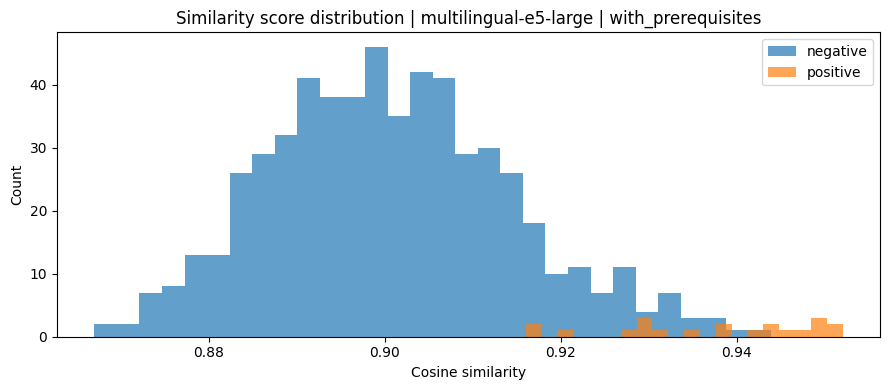

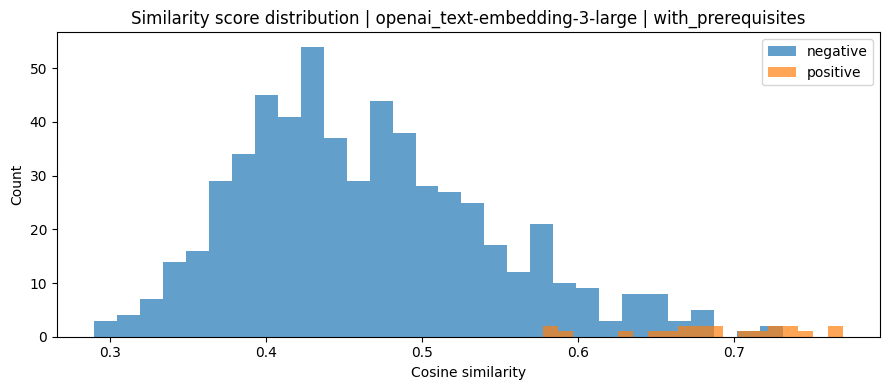

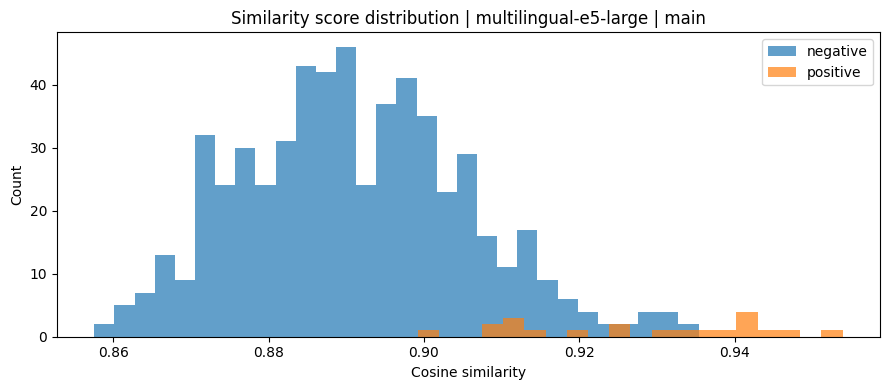

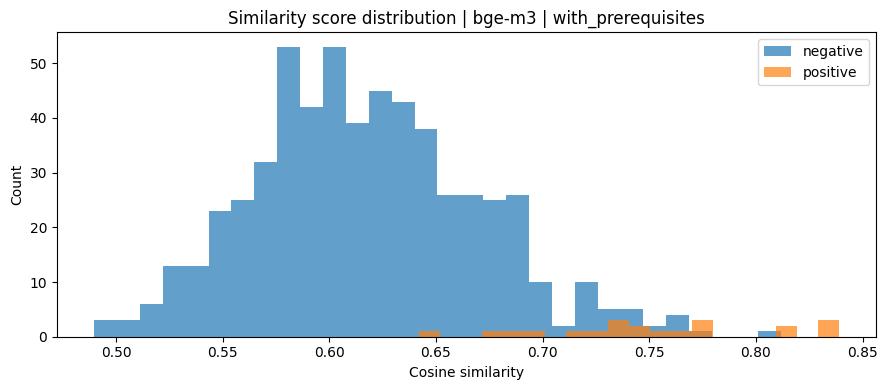

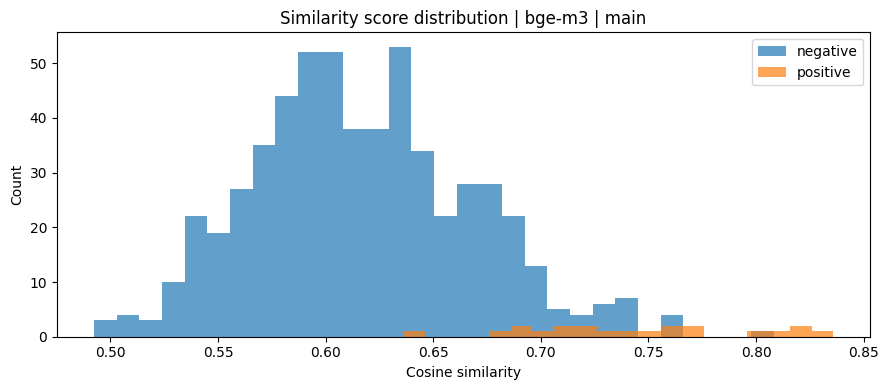

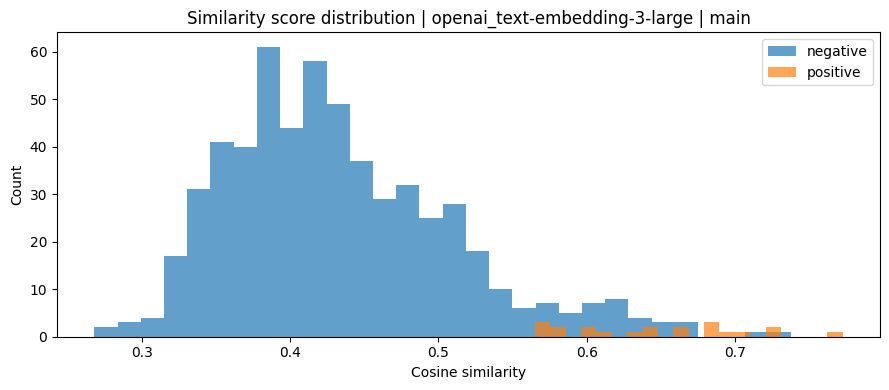

In [211]:
# Cell 27 - Plot score distributions for the top 6 configurations by Average Precision

top_configs = benchmark_summary_dev_df.head(6)[["model_name", "text_variant"]].to_dict(orient="records")

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant)
    ].copy()

    pos_scores = plot_df.loc[plot_df["overlap_label_binary"] == 1, "similarity_score"]
    neg_scores = plot_df.loc[plot_df["overlap_label_binary"] == 0, "similarity_score"]

    plt.figure(figsize=(9, 4))
    plt.hist(neg_scores, bins=30, alpha=0.7, label="negative")
    plt.hist(pos_scores, bins=20, alpha=0.7, label="positive")
    plt.title(f"Similarity score distribution | {model_name} | {text_variant}")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"hist_{slugify_name(model_name)}__{slugify_name(text_variant)}.png", dpi=150)
    plt.show()

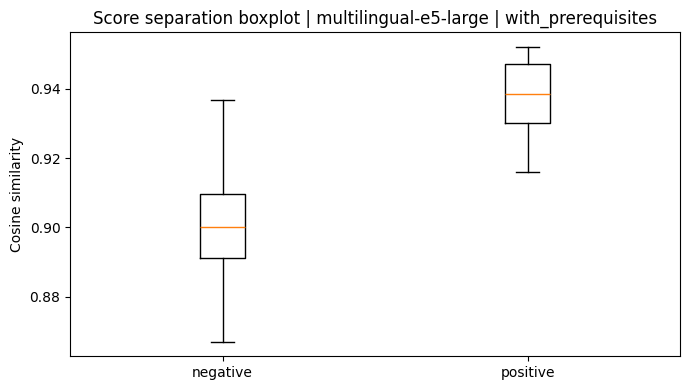

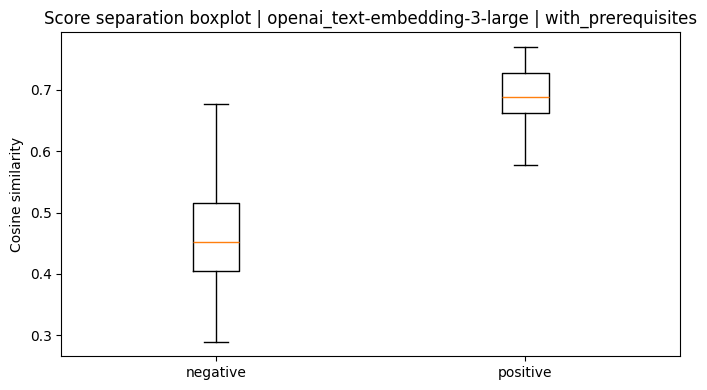

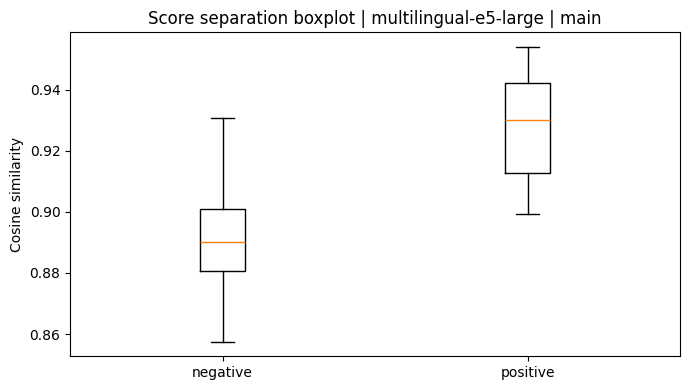

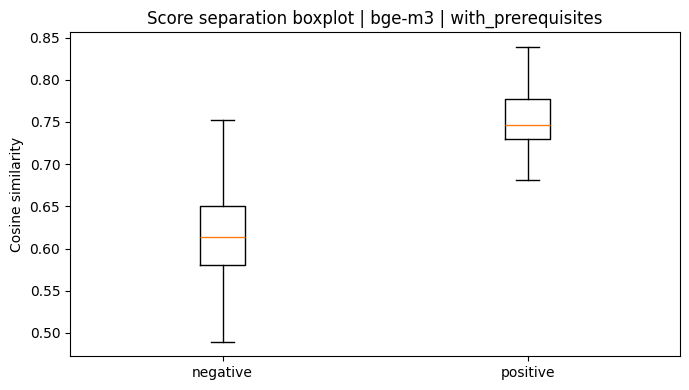

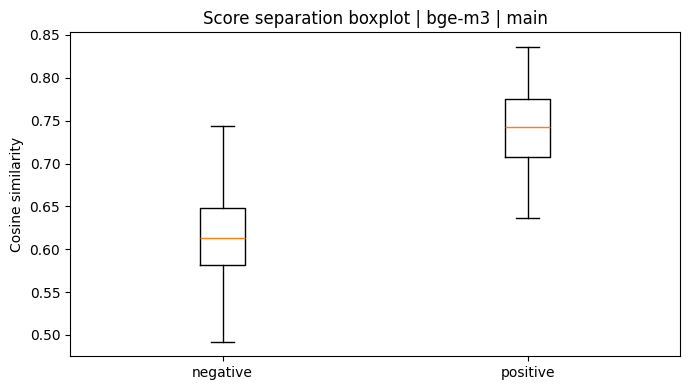

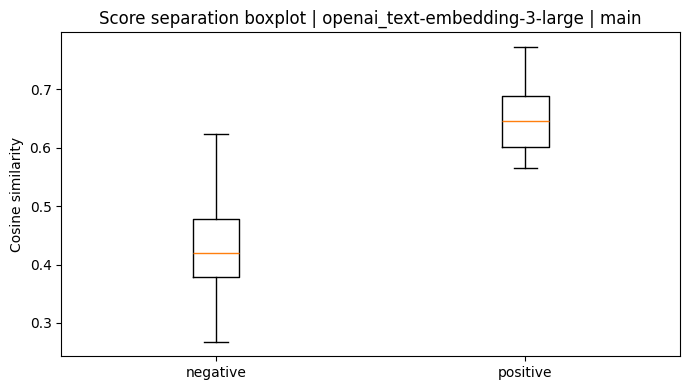

In [212]:
# Cell 28 - Boxplot comparison for the top 6 configurations

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant)
    ].copy()

    neg_scores = plot_df.loc[plot_df["overlap_label_binary"] == 0, "similarity_score"].tolist()
    pos_scores = plot_df.loc[plot_df["overlap_label_binary"] == 1, "similarity_score"].tolist()

    plt.figure(figsize=(7, 4))
    plt.boxplot([neg_scores, pos_scores], labels=["negative", "positive"], showfliers=False)
    plt.title(f"Score separation boxplot | {model_name} | {text_variant}")
    plt.ylabel("Cosine similarity")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"boxplot_{slugify_name(model_name)}__{slugify_name(text_variant)}.png", dpi=150)
    plt.show()

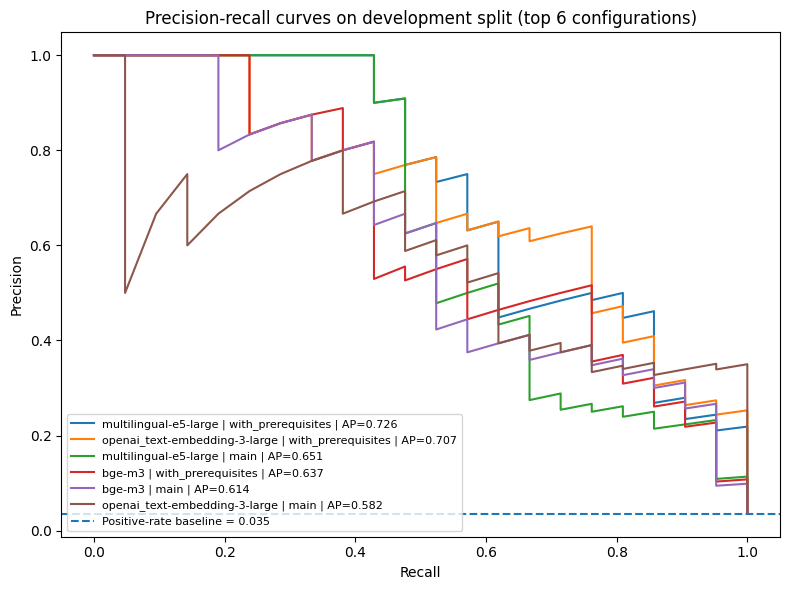

In [213]:
# Cell 29 - Precision-recall curves for the top 6 configurations

plt.figure(figsize=(8, 6))

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(recall_vals, precision_vals, label=f"{model_name} | {text_variant} | AP={ap:.3f}")

baseline_precision = benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Positive-rate baseline = {baseline_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on development split (top 6 configurations)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curves_dev_top6.png", dpi=150)
plt.show()

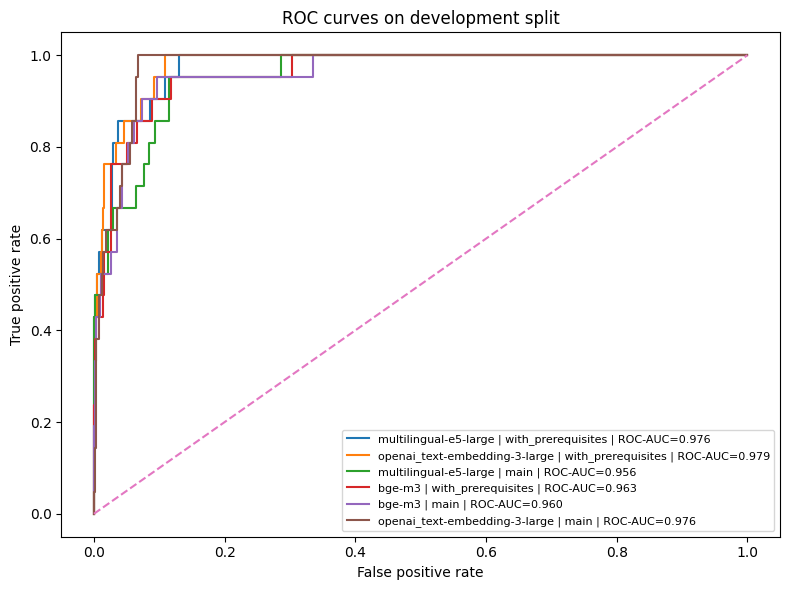

In [214]:
# Cell 30 - ROC curves for the top 6 configurations

plt.figure(figsize=(8, 6))

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    plt.plot(fpr, tpr, label=f"{model_name} | {text_variant} | ROC-AUC={roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on development split")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves_dev_top6.png", dpi=150)
plt.show()

### Inspect top-ranked development pairs and hard false positives

A ranking benchmark should not be judged only by aggregate metrics.

This notebook inspects:
- highest-scoring development pairs overall
- highest-scoring negative pairs (hard false positives)

These cases help reveal where semantic similarity overgeneralizes.

In [215]:
# Cell 32 - Save and display top-ranked development pairs for each configuration

top_pair_rows = []

for (model_name, text_variant), group_df in dev_scores_df.groupby(["model_name", "text_variant"]):
    ranked_df = group_df.sort_values("similarity_score", ascending=False).head(15).copy()
    ranked_df["rank_within_config"] = range(1, len(ranked_df) + 1)
    top_pair_rows.append(ranked_df)

top_ranked_dev_pairs_df = pd.concat(top_pair_rows, ignore_index=True)
top_ranked_dev_pairs_df.to_csv(TOP_PAIRS_CSV_PATH, index=False, encoding="utf-8")

print("Saved top-ranked dev pairs to:", TOP_PAIRS_CSV_PATH)

display(
    top_ranked_dev_pairs_df[[
        "model_name",
        "text_variant",
        "rank_within_config",
        "pair_id",
        "course_name_1",
        "course_name_2",
        "overlap_label_binary",
        "similarity_score",
    ]].head(30)
)

Saved top-ranked dev pairs to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\top_ranked_dev_pairs_by_config.csv


,model_name,text_variant,rank_within_config,pair_id,course_name_1,course_name_2,overlap_label_binary,similarity_score
0,bge-m3,compact,1,TT00CD87__TT00CE11,Information Security Technologies,Data Security Controls,1,0.815971
1,bge-m3,compact,2,TT00CD75__TT00CE25,Windows Basics,Windows Infrastructure,1,0.815179
2,bge-m3,compact,3,TT00CE05__TT00CE06,Data Analytics Project,Machine Learning Project,1,0.797199
3,bge-m3,compact,4,TT00CD87__TT00CD88,Information Security Technologies,Hardening,1,0.796784
4,bge-m3,compact,5,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0,0.795221
5,bge-m3,compact,6,TT00CD84__TT00CE00,Data analytics and artificial intelligence,Data Analysis and Visualization,0,0.782796
6,bge-m3,compact,7,TT00CD86__TT00CD87,Cyber Security,Information Security Technologies,1,0.780953
7,bge-m3,compact,8,TT00CD99__TT00CE00,Data Sources and Data Preprocessing,Data Analysis and Visualization,1,0.767390
8,bge-m3,compact,9,TT00CD72__TT00CE21,Servers and containers,Cloud Architectures and Platforms,1,0.764005
9,bge-m3,compact,10,TT00CE07__TT00CE11,Cyber Security Management,Data Security Controls,0,0.761827


In [216]:
# Cell 33 - Hard false positives: highest-scoring negative pairs for each configuration

hard_false_positive_rows = []

for (model_name, text_variant), group_df in dev_scores_df.groupby(["model_name", "text_variant"]):
    negatives_df = group_df[group_df["overlap_label_binary"] == 0].copy()
    hardest_df = negatives_df.sort_values("similarity_score", ascending=False).head(5).copy()
    hardest_df["hard_false_positive_rank"] = range(1, len(hardest_df) + 1)
    hard_false_positive_rows.append(hardest_df)

hard_false_positives_df = pd.concat(hard_false_positive_rows, ignore_index=True)
hard_false_positives_df.to_csv(HARD_FALSE_POSITIVES_CSV_PATH, index=False, encoding="utf-8")

print("Saved hard false positives to:", HARD_FALSE_POSITIVES_CSV_PATH)

display(
    hard_false_positives_df[[
        "model_name",
        "text_variant",
        "hard_false_positive_rank",
        "pair_id",
        "course_name_1",
        "course_name_2",
        "similarity_score",
    ]].head(30)
)

Saved hard false positives to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\hard_false_positives_dev_top5_by_config.csv


,model_name,text_variant,hard_false_positive_rank,pair_id,course_name_1,course_name_2,similarity_score
0,bge-m3,compact,1,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0.795221
1,bge-m3,compact,2,TT00CD84__TT00CE00,Data analytics and artificial intelligence,Data Analysis and Visualization,0.782796
2,bge-m3,compact,3,TT00CE07__TT00CE11,Cyber Security Management,Data Security Controls,0.761827
3,bge-m3,compact,4,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0.758644
4,bge-m3,compact,5,TT00CD87__TT00CE07,Information Security Technologies,Cyber Security Management,0.747057
5,bge-m3,main,1,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0.808294
6,bge-m3,main,2,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0.763779
7,bge-m3,main,3,TT00CD89__TT00CE09,Software Testing,Auditing and Penetration Testing,0.758281
8,bge-m3,main,4,TT00CE07__TT00CE11,Cyber Security Management,Data Security Controls,0.757502
9,bge-m3,main,5,TT00CD84__TT00CE00,Data analytics and artificial intelligence,Data Analysis and Visualization,0.756314


### Select shortlist candidates for Notebook 04

Notebook 04 should focus on a manageable set of strong candidates.

This shortlist keeps:
- the best variant for each **model name**
- plus the best `main` variant overall if `main` is not already sufficiently represented

In [217]:
# Cell 35 - Build shortlist for Notebook 04 by model_name, preserving one main-variant comparison

best_per_model_df = (
    benchmark_summary_dev_df
    .sort_values(["model_name", "average_precision", "roc_auc"], ascending=[True, False, False])
    .groupby("model_name", as_index=False)
    .head(1)
    .copy()
)

best_main_df = benchmark_summary_dev_df[benchmark_summary_dev_df["text_variant"] == "main"].copy()
best_main_row = None
if not best_main_df.empty:
    best_main_row = best_main_df.sort_values(["average_precision", "roc_auc"], ascending=[False, False]).head(1)

shortlist_df = best_per_model_df.copy()

if best_main_row is not None:
    candidate_model = best_main_row.iloc[0]["model_name"]
    candidate_variant = best_main_row.iloc[0]["text_variant"]
    already_present = (
        (shortlist_df["model_name"] == candidate_model) &
        (shortlist_df["text_variant"] == candidate_variant)
    ).any()
    if not already_present:
        shortlist_df = pd.concat([shortlist_df, best_main_row], ignore_index=True)

shortlist_df = shortlist_df.sort_values(
    ["average_precision", "roc_auc"],
    ascending=[False, False]
).reset_index(drop=True)

# Keep a practical Notebook 04 shortlist size
SHORTLIST_LIMIT = 5
shortlist_df = shortlist_df.head(SHORTLIST_LIMIT).copy()

shortlist_df["shortlist_rank"] = range(1, len(shortlist_df) + 1)
shortlist_df.to_csv(SHORTLIST_CSV_PATH, index=False, encoding="utf-8")

print("Saved shortlist to:", SHORTLIST_CSV_PATH)
display(shortlist_df)

Saved shortlist to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\shortlist_for_notebook_04.csv


,model_name,text_variant,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,shortlist_rank
0,multilingual-e5-large,with_prerequisites,595,21,574,0.035294,0.937562,0.900744,0.036818,0.938471,0.899970,0.038501,0.726140,20.573974,0.976190,1
1,openai_text-embedding-3-large,with_prerequisites,595,21,574,0.035294,0.685292,0.465004,0.220288,0.687776,0.452466,0.235310,0.707060,20.033373,0.979094,2
2,multilingual-e5-large,main,595,21,574,0.035294,0.927989,0.891070,0.036919,0.930202,0.889993,0.040209,0.650668,18.435597,0.956280,3
3,bge-m3,with_prerequisites,595,21,574,0.035294,0.752957,0.617600,0.135356,0.746244,0.613092,0.133152,0.636988,18.048007,0.962585,4
4,multilingual-e5-base,with_prerequisites,595,21,574,0.035294,0.934155,0.902366,0.031789,0.935275,0.901882,0.033394,0.574757,16.284794,0.949643,5


##### Shortlist Construction for Notebook 04

Notebook 04 uses a compact shortlist to keep threshold evaluation focused:
- The shortlist preserves model diversity and includes at least one main-variant comparison.  

TF-IDF is retained as the lexical baseline regardless of its rank position:
- Its presence is essential for the thesis comparison between lexical and semantic approaches. 

E5-base is excluded from the final shortlist when its development ranking quality is clearly below E5-large:
- Because E5-large already represents that model family more strongly


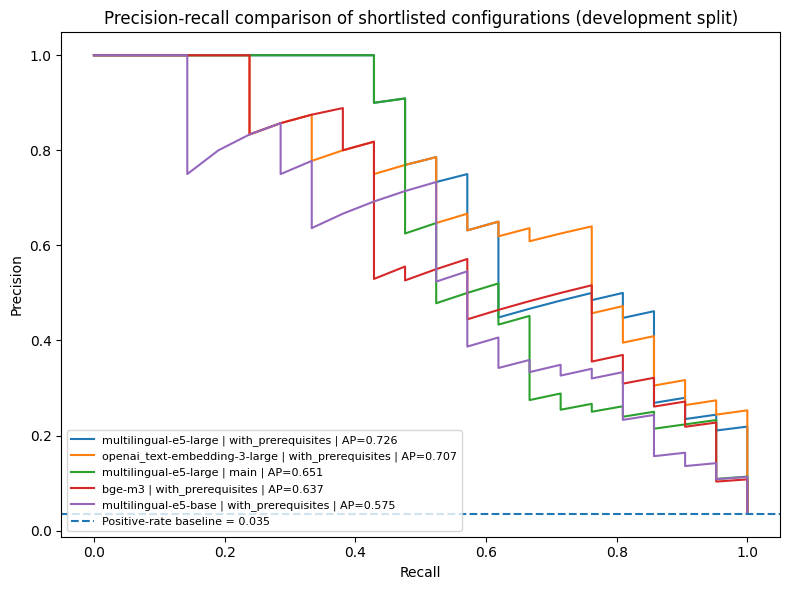

Saved shortlist PR comparison plot to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\benchmark\precision_recall_curves_dev_shortlist.png


In [218]:
# Cell 36 - Final comparison plot: best variant from each shortlisted model

comparison_df = shortlist_df[["model_name", "text_variant"]].drop_duplicates().copy()

plt.figure(figsize=(8, 6))

for _, row in comparison_df.iterrows():
    model_name = row["model_name"]
    text_variant = row["text_variant"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(recall_vals, precision_vals, label=f"{model_name} | {text_variant} | AP={ap:.3f}")

baseline_precision = benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Positive-rate baseline = {baseline_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall comparison of shortlisted configurations (development split)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()

shortlist_pr_plot_path = FIGURES_DIR / "precision_recall_curves_dev_shortlist.png"
plt.savefig(shortlist_pr_plot_path, dpi=150)
plt.show()

print("Saved shortlist PR comparison plot to:", shortlist_pr_plot_path)

### Interpretation guide for thesis writing

When writing up Notebook 03 in the thesis, the main interpretation should focus on:

- whether semantic models outperform the TF-IDF baseline
- whether `compact`, `main`, or `with_prerequisites` produces the clearest separation
- whether the best method produces practically useful score separation
- whether hard false positives reveal consistent semantic overgeneralization patterns

Important:
- high ROC-AUC alone is not enough
- raw accuracy is not meaningful under strong class imbalance
- final threshold tuning belongs to Notebook 04
- Average Precision and AP lift above prevalence are the most useful ranking summaries here
- the `similarity_mean_gap` and `similarity_median_gap` columns are practically important because a very small positive-vs-negative score gap can make threshold selection fragile

Potential thesis-worthy findings to check explicitly:
- whether `with_prerequisites` improves ranking consistently across models
- whether `compact` can outperform `main` for some model families, suggesting that extra structured text may add noise rather than signal
- whether some models achieve strong ranking metrics but still show compressed score ranges, making thresholding less stable in practice
- whether TF-IDF performs competitively because overlapping course pairs often share strong domain-specific vocabulary and exact technical terms

In [219]:
# Cell 38 - Winner summary for Notebook 04

best_row = benchmark_summary_dev_df.iloc[0]

dev_pair_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev"].shape[0])
dev_positive_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].sum())
test_pair_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "test"].shape[0])
test_positive_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "test", "overlap_label_binary"].sum())

print("Best development configuration overall:")
print(f"  Model: {best_row['model_name']}")
print(f"  Text variant: {best_row['text_variant']}")
print(f"  Average Precision: {best_row['average_precision']:.4f}")
print(f"  AP lift vs prevalence: {best_row['ap_lift_vs_prevalence']:.2f}x")
print(f"  ROC-AUC: {best_row['roc_auc']:.4f}")
print(f"  Mean similarity gap: {best_row['similarity_mean_gap']:.4f}")
print(f"  Median similarity gap: {best_row['similarity_median_gap']:.4f}")
print()

print("Evaluation context:")
print(f"  Dev pairs: {dev_pair_count}")
print(f"  Dev positives: {dev_positive_count}")
print(f"  Test pairs: {test_pair_count}")
print(f"  Test positives: {test_positive_count}")
print()

openai_best_df = benchmark_summary_dev_df[
    benchmark_summary_dev_df["model_name"] == "openai_text-embedding-3-large"
].sort_values(["average_precision", "roc_auc"], ascending=[False, False])

e5_large_best_df = benchmark_summary_dev_df[
    benchmark_summary_dev_df["model_name"] == "multilingual-e5-large"
].sort_values(["average_precision", "roc_auc"], ascending=[False, False])

if not openai_best_df.empty:
    openai_best_row = openai_best_df.iloc[0]
    print("Best OpenAI configuration:")
    print(f"  Text variant: {openai_best_row['text_variant']}")
    print(f"  Average Precision: {openai_best_row['average_precision']:.4f}")
    print(f"  Mean similarity gap: {openai_best_row['similarity_mean_gap']:.4f}")
    print()

if not e5_large_best_df.empty:
    e5_large_best_row = e5_large_best_df.iloc[0]
    print("Best multilingual-e5-large configuration:")
    print(f"  Text variant: {e5_large_best_row['text_variant']}")
    print(f"  Average Precision: {e5_large_best_row['average_precision']:.4f}")
    print(f"  Mean similarity gap: {e5_large_best_row['similarity_mean_gap']:.4f}")
    print()

print("Notebook 04 should begin by evaluating the shortlisted configurations with tuned thresholds.")
print("In Notebook 04, pay special attention to models with very small similarity-gap values, because their threshold behavior may be more fragile.")
print("Also interpret final test metrics cautiously, because the test split still contains only a small number of positive pairs.")

Best development configuration overall:
  Model: multilingual-e5-large
  Text variant: with_prerequisites
  Average Precision: 0.7261
  AP lift vs prevalence: 20.57x
  ROC-AUC: 0.9762
  Mean similarity gap: 0.0368
  Median similarity gap: 0.0385

Evaluation context:
  Dev pairs: 595
  Dev positives: 21
  Test pairs: 105
  Test positives: 5

Best OpenAI configuration:
  Text variant: with_prerequisites
  Average Precision: 0.7071
  Mean similarity gap: 0.2203

Best multilingual-e5-large configuration:
  Text variant: with_prerequisites
  Average Precision: 0.7261
  Mean similarity gap: 0.0368

Notebook 04 should begin by evaluating the shortlisted configurations with tuned thresholds.
In Notebook 04, pay special attention to models with very small similarity-gap values, because their threshold behavior may be more fragile.
Also interpret final test metrics cautiously, because the test split still contains only a small number of positive pairs.


## Final note

Notebook 03 benchmarks **score quality** across lexical and dense embedding methods using a **course-level** development/test split.

### What this notebook does well
- aligns evaluation more closely with held-out generalization than a pair-level split
- compares multiple text variants instead of assuming one representation is best
- includes a lexical baseline for context
- separates model screening from later threshold selection
- saves reusable benchmark artifacts for Notebook 04
- includes both quantitative ranking metrics and qualitative error inspection

### Why this design is appropriate
This thesis is not only about producing a similarity score. It is about understanding which representation and embedding method produces scores that are most useful for overlap detection under realistic class imbalance. That is why Notebook 03 focuses on ranking quality, score separation, and error patterns rather than final threshold tuning.

### Important limitations
- The dataset is small and overlap pairs are rare.
- The course-level split is constructed using a constrained search to preserve a minimally usable number of positive pairs in both dev and test.
- Some labeled positive pairs are excluded from both development and test evaluation because mixed pairs are discarded.
- Even after improvement, the test set still contains only a small number of positive pairs, so Notebook 04 threshold metrics should be interpreted cautiously.

Notebook 04 will use the shortlisted configurations from this notebook to choose and evaluate operating thresholds more carefully.